In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from plot import make_theme

%matplotlib inline
plt.rcParams['font.size'] = 7

In [2]:
def plot_label(ax, count, x=0, y=1.03, color='k'):
    ax.text(x, y, count, fontdict=dict(fontsize=9), transform=ax.transAxes, color=color, weight='bold')

def fit_peak(x, y, x0=0, bg=None, fraction=False):
    model = lmfit.models.ConstantModel(prefix='bg_') + lmfit.models.PseudoVoigtModel(prefix='p_')
    params = model.make_params()
    if bg is None:
        params['bg_c'].set(value=0.1, min=0., max=1e3)
    else:
        params['bg_c'].set(value=bg, vary=False)
    params['p_sigma'].set(value=0.01, min=1e-5, max=0.1)
    params['p_amplitude'].set(value=100., min=1e-3, max=1e5)
    params['p_center'].set(value=x0, min=x0-0.02, max=x0+0.02)
    params['p_fraction'].set(value=0., min=0., max=1., vary=fraction) # fraction=0 for Gaussian
    result = model.fit(y, x=x, params=params)
    print(result.message)
    return result, model.eval(params=result.params, x=x)

In [3]:
scan_list = [342,269,187,78]
edges = ['Mn', 'Fe', 'Co', 'Ni']
colors = ['C4','C3','royalblue','C2']
fmts = ['o', 's', 'D', 'p']
mkss = [6.5, 6, 6, 8]
Lrlus = [0.21, 0.37, 0.4, 0.61]

Fit succeeded.
Fit succeeded.
Fit succeeded.
Fit succeeded.
Fit succeeded.
Fit succeeded.
Fit succeeded.
Fit succeeded.
Fit succeeded.
Fit succeeded.
Fit succeeded.
Fit succeeded.
Fit succeeded.
Fit succeeded.
Fit succeeded.
Fit succeeded.
Fit succeeded.
Fit succeeded.
Fit succeeded.
Fit succeeded.
Fit succeeded.
Fit succeeded.


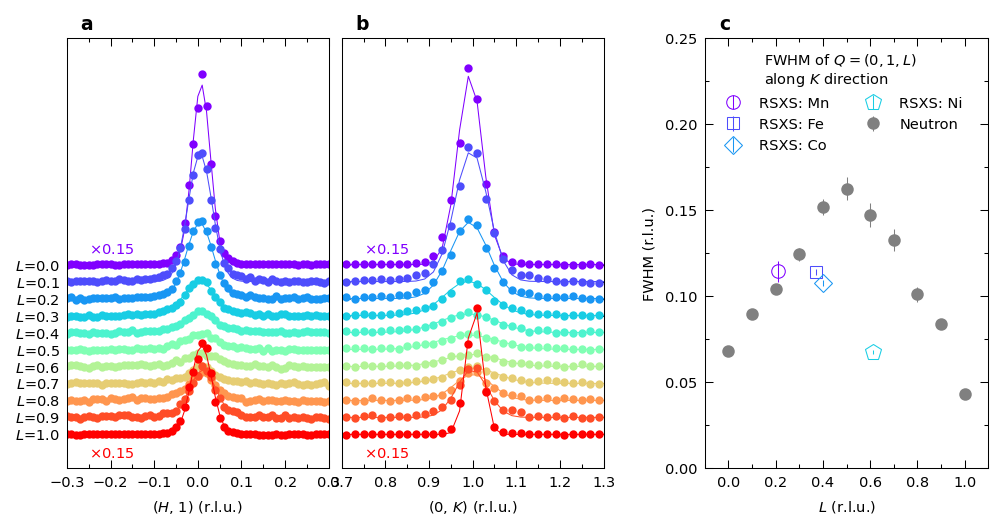

In [4]:
fig = plt.figure(figsize=(6.75,6.75/2), dpi=150)
gs1 = fig.add_gridspec(nrows=1, ncols=2, left=0.07, right=0.60, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
gs2 = fig.add_gridspec(nrows=1, ncols=1, left=0.70, right=0.98, top=0.95, bottom=0.1, wspace=0, hspace=0.2)
axs = [fig.add_subplot(gs) for gs in gs1]
axs += [fig.add_subplot(gs) for gs in gs2]

data = dict(np.load('../corelli/HEPS3_HKL_006K.npz'))
Ls = np.arange(0.,1.01,0.1)
yshift = -0.15
colors = plt.cm.rainbow(np.linspace(0,1,len(Ls)))

# Hcuts
ax = axs[0]
dHKL = [0.5,0.04,0.05]
for nL, L in enumerate(Ls):
    HKL = [0.,1.,L]
    if abs(L)<=0.01 or abs(L-1)<=0.01:
        yscale = 0.15
    else:
        yscale = 1.
    chooseH = np.abs(data['Hrlu']-HKL[0])<=dHKL[0]
    chooseK = np.abs(data['Krlu']-HKL[1])<=dHKL[1]
    chooseL = np.abs(data['Lrlu']-HKL[2])<=dHKL[2]
    x = data['Hrlu'][chooseH]
    y = data['I'][chooseL,:,:][:,chooseK,:][:,:,chooseH].mean(axis=(0,1))
    choose = np.abs(x-HKL[0])>=0.3
    bg = y[choose].mean()
    result, y_fit = fit_peak(x, y, bg=bg, x0=0., fraction=False)
    ax.plot(x, (y-bg)*yscale+yshift*nL, 'o', ms=3, color=colors[nL])
    ax.plot(x, (y_fit-bg)*yscale+yshift*nL, '-', lw=0.5, color=colors[nL])
## config
make_theme(ax, minory=False, ticklength=4)
ax.text(-0.25, -1.7, '$\\times$0.15', color=colors[-1])
ax.text(-0.25, 0.1, '$\\times$0.15', color=colors[0])
ax.set_xlim(-0.3, 0.3)
ax.set_xticks(np.arange(-0.3,0.31,0.1))
ax.set_xlabel('($H$, 1) (r.l.u.)')
ax.set_ylim(-1.8, 2)
ax.set_yticks(np.arange(len(Ls))*yshift)
ax.set_yticklabels(['$L$={:.1f}'.format(L) for L in Ls])
plot_label(ax, 'a', x=0.05, y=1.02)

# Kcuts
ax = axs[1]
dHKL = [0.02,0.5,0.05]
widths = []
for nL, L in enumerate(Ls):
    if abs(L)<=0.01 or abs(L-1)<=0.01:
        yscale = 0.15
    else:
        yscale = 1.
    HKL = [0.,1.,L]
    chooseH = np.abs(data['Hrlu']-HKL[0])<=dHKL[0]
    chooseK = np.abs(data['Krlu']-HKL[1])<=dHKL[1]
    chooseL = np.abs(data['Lrlu']-HKL[2])<=dHKL[2]
    x = data['Krlu'][chooseK]
    y = data['I'][chooseL,:,:][:,chooseK,:][:,:,chooseH].mean(axis=(0,2))
    choose = np.abs(x-HKL[1])>=0.3
    bg = y[choose].mean()
    result, y_fit = fit_peak(x, y, bg=bg, x0=1., fraction=False)
    widths.append([result.params['p_fwhm'].value, result.params['p_fwhm'].stderr])
    ax.plot(x, (y-bg)*yscale+yshift*nL, 'o', ms=3, color=colors[nL])
    ax.plot(x, (y_fit-bg)*yscale+yshift*nL, '-', lw=0.5, color=colors[nL])
widths = np.vstack(widths)
## config
make_theme(ax, minory=False, ticklength=4)
ax.text(0.75, -1.7, '$\\times$0.15', color=colors[-1])
ax.text(0.75, 0.1, '$\\times$0.15', color=colors[0])
ax.set_xlim(0.7, 1.3)
ax.set_xticks(np.arange(0.7,1.31,0.1))
ax.set_xlabel('(0, $K$) (r.l.u.)')
ax.set_ylim(-1.8, 2)
ax.set_yticks(np.arange(len(Ls))*yshift)
ax.tick_params(labelleft=False)
plot_label(ax, 'b', x=0.05, y=1.02)

# L-dep width
ax = axs[2]
## REIXS
plot_params = dict(elinewidth=0.5, ls='none', mew=0.5, mfc='none')
for scan_no, edge, color, fmt, mks, Lrlu in zip(scan_list, edges, colors, fmts, mkss, Lrlus):
    fit_result = dict(np.load('../reixs/fits/results_{}.npz'.format(scan_no)))
    ax.errorbar(Lrlu, fit_result['p_fwhm'][0], fit_result['p_fwhm'][1], fmt=fmt, ms=mks, color=color, label='RSXS: '+edge, **plot_params)
## neutron diffraction
ax.errorbar(Ls, widths[:,0], yerr=widths[:,1], fmt='o', color='gray', elinewidth=0.5, ms=5, zorder=-1, label='Neutron')

## config
ax.legend(loc='upper left', frameon=False, ncol=2, markerscale=1,
          title='FWHM of $Q=(0, 1, L)$\nalong $K$ direction')
make_theme(ax, ticklength=4)
ax.set_xlim(-0.1, 1.1)
ax.set_xticks(np.arange(0.,1.01,0.2))
ax.set_xlabel('$L$ (r.l.u.)')
ax.set_ylim(0,0.25)
ax.set_yticks(np.arange(0.,0.251,0.05))
ax.set_ylabel('FWHM (r.l.u.)')
plot_label(ax, 'c', x=0.05, y=1.02)

# fig.savefig('width.pdf')